# 01 — Exploratory Data Analysis: M5 Walmart Sales Forecasting

**Goal:** Load, clean, and explore the M5 Walmart dataset to understand sales patterns, 
seasonality, and data structure. Every finding here drives a direct modeling decision 
in subsequent notebooks.

**Dataset:** M5 Forecasting — Accuracy (Kaggle, 2020)  
**Files:** `sales_train_validation.csv`, `calendar.csv`, `sell_prices.csv`

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)

np.random.seed(42)

## 2. Load Raw Data

The M5 dataset comes in three separate files that each serve a different purpose. 
`sales_train_validation.csv` is in **wide format** — each column is a day — which we 
must melt into long format before any analysis is possible. `calendar.csv` maps day 
IDs to real dates and contains holiday/event/SNAP flags. `sell_prices.csv` gives us 
weekly prices per product per store, which we use to compute revenue.

In [2]:
# Load all three files
sales_wide = pd.read_csv('../data/raw/sales_train_validation.csv')
calendar   = pd.read_csv('../data/raw/calendar.csv')
prices     = pd.read_csv('../data/raw/sell_prices.csv')

print('sales_train_validation shape:', sales_wide.shape)
print('calendar shape:              ', calendar.shape)
print('sell_prices shape:           ', prices.shape)
print()
print('Sales columns (first 10):', sales_wide.columns[:10].tolist())
print('Sales columns (last 5):  ', sales_wide.columns[-5:].tolist())
print()
print('Calendar columns:', calendar.columns.tolist())
print()
print('Prices columns:  ', prices.columns.tolist())
print()
sales_wide.head(3)

sales_train_validation shape: (30490, 1919)
calendar shape:               (1969, 14)
sell_prices shape:            (6841121, 4)

Sales columns (first 10): ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4']
Sales columns (last 5):   ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']

Calendar columns: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Prices columns:   ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']



,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1


## 3. Reshape: Wide → Long Format

The sales data has one row per product-store and one column per day (d_1 through d_1913). 
We melt this into long format — one row per product-store-day — so we can join with 
calendar dates and perform time series operations. This is the core reshaping step 
that unlocks all downstream analysis.

In [19]:
# ID columns to keep as-is
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

# Day columns (d_1 through d_1913)
day_cols = [c for c in sales_wide.columns if c.startswith('d_')]

# Melt wide → long
sales_long = sales_wide.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name='d',
    value_name='units_sold'
)

print('Long format shape:', sales_long.shape)
print('Expected:         ', len(sales_wide) * len(day_cols))
print()
sales_long.head(10)

Long format shape: (58327370, 8)
Expected:          58327370



,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
5,HOBBIES_1_006_CA_1_validation,HOBBIES_1_006,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
6,HOBBIES_1_007_CA_1_validation,HOBBIES_1_007,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_1,12
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,d_1,2
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


## 4. Join Calendar and Prices

We join the calendar to get real dates, weekdays, and event flags for each day ID. 
We then join prices to compute daily revenue (`units_sold × sell_price`). 
Prices are weekly so we merge on `store_id`, `item_id`, and `wm_yr_wk` (week ID).

In [4]:
# Keep only needed calendar columns
cal_cols = ['d', 'date', 'wm_yr_wk', 'weekday', 'month', 'year',
            'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI']
calendar_slim = calendar[cal_cols].copy()

# Join calendar
df = sales_long.merge(calendar_slim, on='d', how='left')

# Join prices
df = df.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# Parse date
df['date'] = pd.to_datetime(df['date'])

# Compute revenue
df['revenue'] = df['units_sold'] * df['sell_price']

# Sort chronologically
df = df.sort_values(['id', 'date']).reset_index(drop=True)

print('Joined dataframe shape:', df.shape)
print()
print(df.dtypes)
print()
df.head(3)

Joined dataframe shape: (58327370, 20)

id                      object
item_id                 object
dept_id                 object
cat_id                  object
store_id                object
state_id                object
d                       object
units_sold               int64
date            datetime64[ns]
wm_yr_wk                 int64
weekday                 object
month                    int64
year                     int64
event_name_1            object
event_type_1            object
snap_CA                  int64
snap_TX                  int64
snap_WI                  int64
sell_price             float64
revenue                float64
dtype: object



,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,weekday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,sell_price,revenue
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,2011,NaN,NaN,0,0,0,2.0,6.0
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,1,2011,NaN,NaN,0,0,0,2.0,0.0
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,Monday,1,2011,NaN,NaN,0,0,0,2.0,0.0


## 5. Data Quality Checks

Before exploring patterns we verify date range, missing values, and the structure 
of the dataset. Missing prices are expected — products not sold in a given week 
have no price entry, which is a data structure issue not a data quality problem.

In [5]:
print('Date range:')
print('  Start:', df['date'].min())
print('  End:  ', df['date'].max())
print()
print('Unique products (item_id):        ', df['item_id'].nunique())
print('Unique stores:                    ', df['store_id'].nunique())
print('Unique product-store series:      ', df['id'].nunique())
print('Unique departments (dept_id):     ', df['dept_id'].nunique())
print('Unique categories (cat_id):       ', df['cat_id'].nunique())
print('Unique states:                    ', df['state_id'].nunique())
print()
print('Categories:', df['cat_id'].unique().tolist())
print('Departments:', df['dept_id'].unique().tolist())
print('Stores:', df['store_id'].unique().tolist())
print()
print('Missing values:')
print(df[['units_sold', 'sell_price', 'revenue', 'event_name_1']].isnull().sum())
print()
print('Units sold stats:')
print(df['units_sold'].describe().round(2))
print()
print('Revenue stats (excl. missing price):')
print(df['revenue'].describe().round(2))

Date range:
  Start: 2011-01-29 00:00:00
  End:   2016-04-24 00:00:00

Unique products (item_id):         3049
Unique stores:                     10
Unique product-store series:       30490
Unique departments (dept_id):      7
Unique categories (cat_id):        3
Unique states:                     3

Categories: ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Departments: ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']
Stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']

Missing values:
units_sold             0
sell_price      12299413
revenue         12299413
event_name_1    53631910
dtype: int64

Units sold stats:
count    58327370.00
mean            1.13
std             3.87
min             0.00
25%             0.00
50%             0.00
75%             1.00
max           763.00
Name: units_sold, dtype: float64

Revenue stats (excl. missing price):
count    46027957.00
mean            4.08
std            10.66
min      

## 6. Handle Missing Prices

Products have missing prices for periods before they were introduced to a store. 
These rows have zero or no sales anyway, so we fill missing revenue with 0. 
We also create a clean `month_dt` column for monthly aggregations.

In [6]:
# Fill missing revenue with 0 (product not yet in store = no sales)
df['revenue'] = df['revenue'].fillna(0)
df['sell_price'] = df['sell_price'].fillna(0)

# Month period for aggregation
df['month_dt'] = df['date'].dt.to_period('M').dt.to_timestamp()

print('Missing values after fill:')
print(df[['units_sold', 'sell_price', 'revenue']].isnull().sum())
print()
print('Date range confirmed:', df['date'].min(), '→', df['date'].max())
print('Total months:        ', df['month_dt'].nunique())

Missing values after fill:
units_sold    0
sell_price    0
revenue       0
dtype: int64

Date range confirmed: 2011-01-29 00:00:00 → 2016-04-24 00:00:00
Total months:         64


## 7. Category & Department Breakdown

We examine how total revenue is distributed across the 3 categories and 7 departments. 
This tells us which segments drive platform revenue and which are candidates for 
individual series modeling.

Revenue by Category:
   cat_id  revenue_fmt   pct
    FOODS $108,904,622 58.03
HOUSEHOLD  $55,953,543 29.81
  HOBBIES  $22,818,405 12.16

Revenue by Department:
    dept_id revenue_fmt   pct
    FOODS_3 $70,966,590 37.81
HOUSEHOLD_1 $41,261,928 21.99
    FOODS_2 $25,019,508 13.33
  HOBBIES_1 $21,644,358 11.53
HOUSEHOLD_2 $14,691,615  7.83
    FOODS_1 $12,918,523  6.88
  HOBBIES_2  $1,174,048  0.63


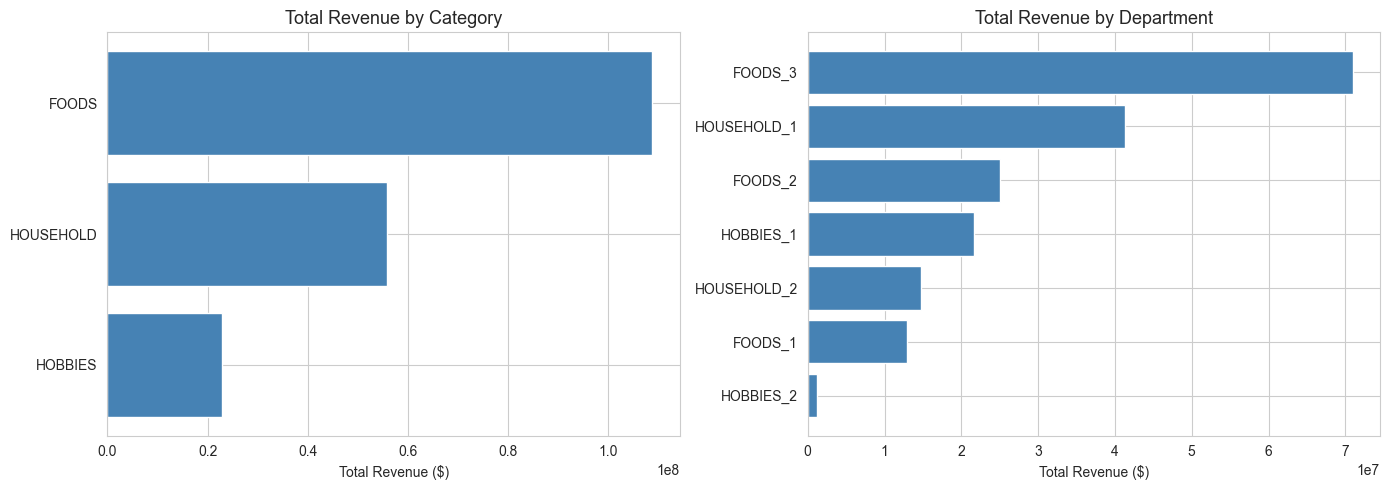

In [7]:
# Category breakdown
cat_totals = (
    df.groupby('cat_id')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
cat_totals['pct'] = (cat_totals['revenue'] / cat_totals['revenue'].sum() * 100).round(2)
cat_totals['revenue_fmt'] = cat_totals['revenue'].apply(lambda x: f'${x:,.0f}')

print('Revenue by Category:')
print(cat_totals[['cat_id', 'revenue_fmt', 'pct']].to_string(index=False))
print()

# Department breakdown
dept_totals = (
    df.groupby('dept_id')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
dept_totals['pct'] = (dept_totals['revenue'] / dept_totals['revenue'].sum() * 100).round(2)
dept_totals['revenue_fmt'] = dept_totals['revenue'].apply(lambda x: f'${x:,.0f}')

print('Revenue by Department:')
print(dept_totals[['dept_id', 'revenue_fmt', 'pct']].to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(cat_totals['cat_id'][::-1], cat_totals['revenue'][::-1], color='steelblue')
axes[0].set_title('Total Revenue by Category', fontsize=13)
axes[0].set_xlabel('Total Revenue ($)')

axes[1].barh(dept_totals['dept_id'][::-1], dept_totals['revenue'][::-1], color='steelblue')
axes[1].set_title('Total Revenue by Department', fontsize=13)
axes[1].set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

## 8. Revenue Distribution

We examine the distribution of daily revenue per product-store series to assess 
skewness and determine whether a log transformation is needed before modeling.

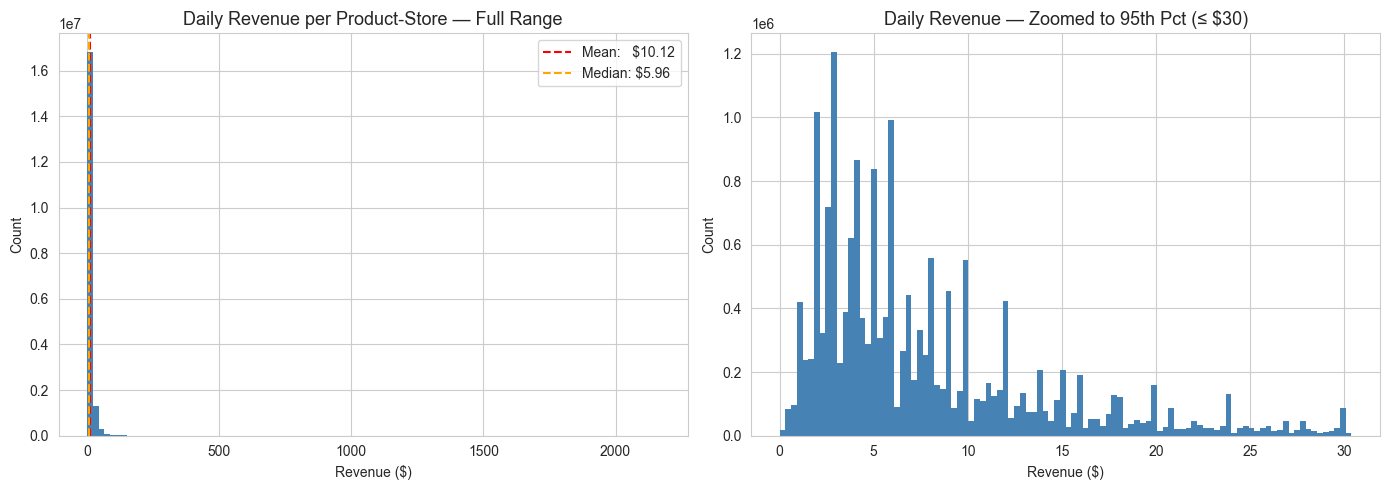

Skewness:            11.03
% days with 0 sales: 68.2%
% revenue under $50: 98.2%
95th percentile:     $30.38
Max daily revenue:   $2,164.32


In [8]:
# Filter to rows with actual sales
sales_nonzero = df[df['revenue'] > 0]['revenue']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sales_nonzero, bins=100, color='steelblue', edgecolor='none')
axes[0].axvline(sales_nonzero.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean:   ${sales_nonzero.mean():.2f}')
axes[0].axvline(sales_nonzero.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: ${sales_nonzero.median():.2f}')
axes[0].set_title('Daily Revenue per Product-Store — Full Range', fontsize=13)
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

p95 = sales_nonzero.quantile(0.95)
axes[1].hist(sales_nonzero[sales_nonzero <= p95], bins=100, color='steelblue', edgecolor='none')
axes[1].set_title(f'Daily Revenue — Zoomed to 95th Pct (≤ ${p95:.0f})', fontsize=13)
axes[1].set_xlabel('Revenue ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Skewness:            {sales_nonzero.skew():.2f}')
print(f'% days with 0 sales: {(df["revenue"] == 0).mean()*100:.1f}%')
print(f'% revenue under $50: {(sales_nonzero < 50).mean()*100:.1f}%')
print(f'95th percentile:     ${p95:,.2f}')
print(f'Max daily revenue:   ${sales_nonzero.max():,.2f}')

## 9. Monthly Trend — Aggregate Series

We aggregate all product-store revenue to monthly totals, producing the primary 
time series we will model with SARIMA and Prophet. We look for visible trend, 
seasonality, and any structural breaks that would affect model choice.

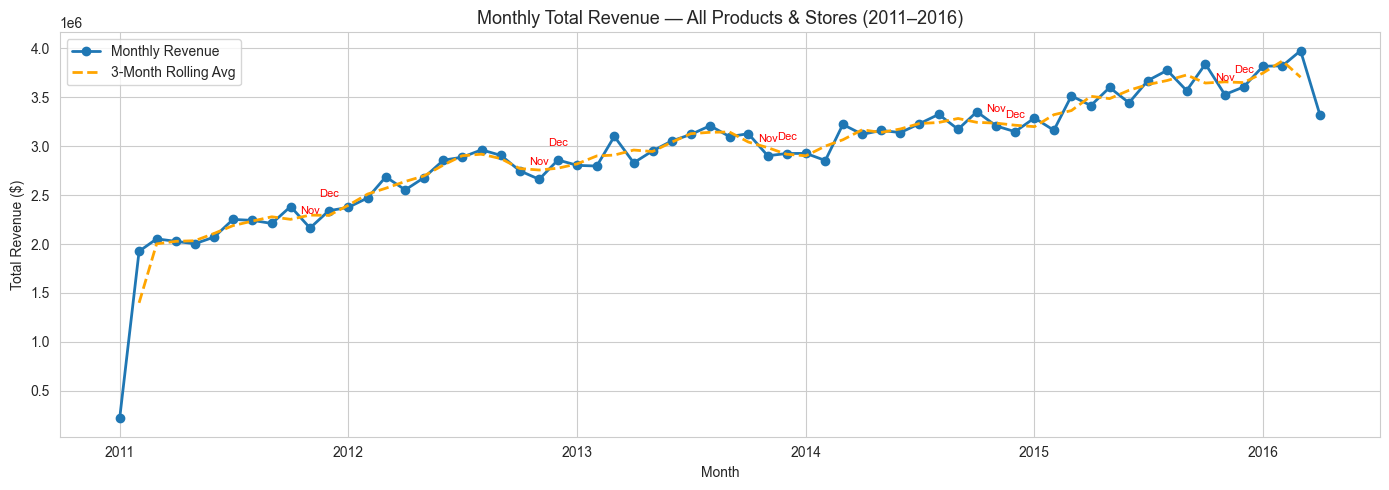

  month_dt  total_revenue
2011-01-01      218328.09
2011-02-01     1925877.70
2011-03-01     2052900.47
2011-04-01     2027413.92
2011-05-01     2002988.04
2011-06-01     2071718.02
2011-07-01     2251854.76
2011-08-01     2241842.59
2011-09-01     2210655.53
2011-10-01     2383437.94
2011-11-01     2163718.00
2011-12-01     2340601.02
2012-01-01     2374646.62
2012-02-01     2471483.03
2012-03-01     2686887.35
2012-04-01     2553341.31
2012-05-01     2678455.39
2012-06-01     2857335.42
2012-07-01     2887577.78
2012-08-01     2963209.22
2012-09-01     2905886.90
2012-10-01     2748864.28
2012-11-01     2661879.59
2012-12-01     2859633.95
2013-01-01     2804198.02
2013-02-01     2797578.45
2013-03-01     3100385.08
2013-04-01     2830527.16
2013-05-01     2952058.26
2013-06-01     3054857.17
2013-07-01     3119858.62
2013-08-01     3209642.23
2013-09-01     3098157.11
2013-10-01     3128223.81
2013-11-01     2902361.12
2013-12-01     2925526.28
2014-01-01     2927020.68
2014-02-01  

In [9]:
monthly = (
    df.groupby('month_dt')['revenue']
    .sum()
    .reset_index()
    .rename(columns={'revenue': 'total_revenue'})
)
monthly['rolling_3'] = monthly['total_revenue'].rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['month_dt'], monthly['total_revenue'], marker='o', linewidth=2, label='Monthly Revenue')
ax.plot(monthly['month_dt'], monthly['rolling_3'], linewidth=2, linestyle='--', color='orange', label='3-Month Rolling Avg')

# Annotate November/December peaks
for _, row in monthly[monthly['month_dt'].dt.month.isin([11, 12])].iterrows():
    label = 'Nov' if row['month_dt'].month == 11 else 'Dec'
    ax.annotate(label, xy=(row['month_dt'], row['total_revenue']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8, color='red')

ax.set_title('Monthly Total Revenue — All Products & Stores (2011–2016)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')
ax.legend()
plt.tight_layout()
plt.show()

print(monthly[['month_dt', 'total_revenue']].to_string(index=False))

## 10. Seasonal Decomposition — Aggregate Series

We formally separate the monthly revenue series into trend, seasonal, and residual 
components. Unlike synthetic data, we expect a non-flat residual here — genuine 
noise from promotions, weather, and economic conditions that no seasonal model 
can fully explain.

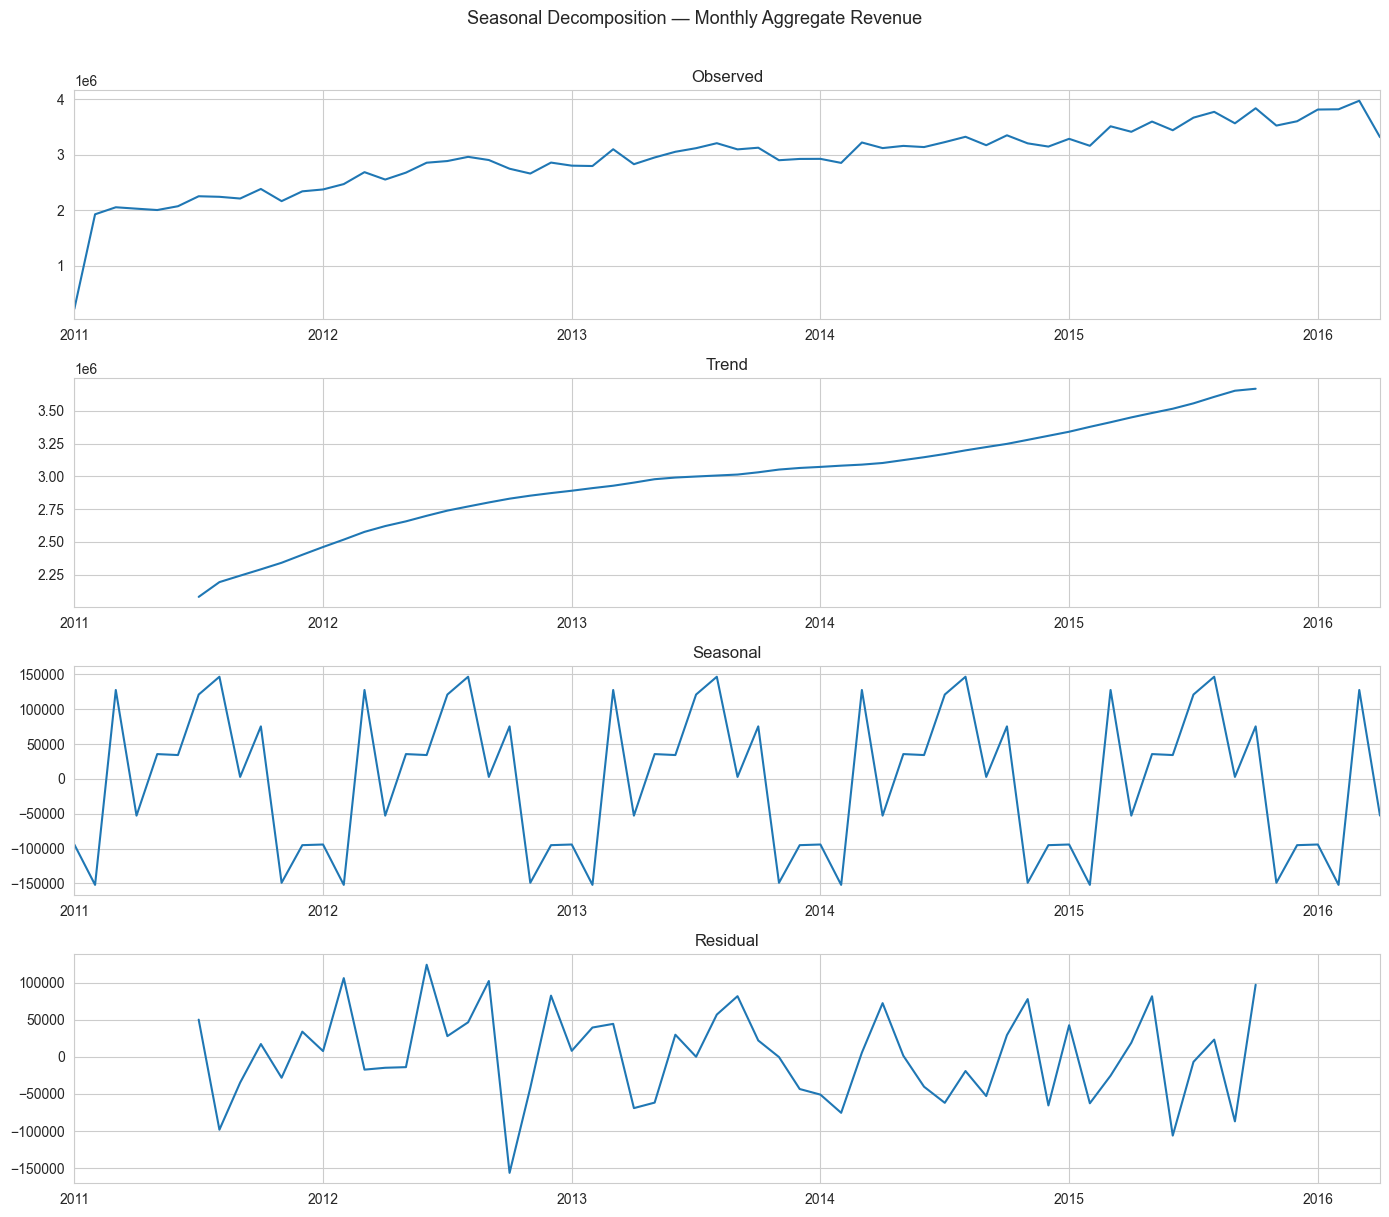

Seasonal component by month:
month_dt
2011-01-01    -94135.0
2011-02-01   -152047.0
2011-03-01    127528.0
2011-04-01    -52720.0
2011-05-01     35578.0
2011-06-01     34202.0
2011-07-01    121000.0
2011-08-01    146543.0
2011-09-01      2835.0
2011-10-01     75327.0
2011-11-01   -149036.0
2011-12-01    -95076.0
2012-01-01    -94135.0
2012-02-01   -152047.0
2012-03-01    127528.0
2012-04-01    -52720.0
2012-05-01     35578.0
2012-06-01     34202.0
2012-07-01    121000.0
2012-08-01    146543.0
2012-09-01      2835.0
2012-10-01     75327.0
2012-11-01   -149036.0
2012-12-01    -95076.0
2013-01-01    -94135.0
2013-02-01   -152047.0
2013-03-01    127528.0
2013-04-01    -52720.0
2013-05-01     35578.0
2013-06-01     34202.0
2013-07-01    121000.0
2013-08-01    146543.0
2013-09-01      2835.0
2013-10-01     75327.0
2013-11-01   -149036.0
2013-12-01    -95076.0
2014-01-01    -94135.0
2014-02-01   -152047.0
2014-03-01    127528.0
2014-04-01    -52720.0
2014-05-01     35578.0
2014-06-01     3420

In [10]:
monthly_indexed = monthly.set_index('month_dt')['total_revenue']

decomp = seasonal_decompose(monthly_indexed, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1],    title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonal')
decomp.resid.plot(ax=axes[3],    title='Residual')
for ax in axes:
    ax.set_xlabel('')
plt.suptitle('Seasonal Decomposition — Monthly Aggregate Revenue', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Seasonal component by month:')
print(decomp.seasonal.round(0).to_string())

## 11. Holiday & Event Impact Analysis

One of the key advantages of M5 over synthetic data is the presence of real 
holidays and promotional events. We quantify how much events like the Super Bowl, 
Thanksgiving, and Christmas affect daily sales — these become features in our 
XGBoost model.

In [11]:
# Average daily revenue on event days vs non-event days
daily = df.groupby(['date', 'event_name_1'])['revenue'].sum().reset_index()
daily.columns = ['date', 'event_name', 'daily_revenue']

no_event_avg = daily[daily['event_name'].isna()]['daily_revenue'].mean()
print(f'Average daily revenue — no event: ${no_event_avg:,.0f}')
print()

# Top events by average daily revenue
event_avg = (
    daily[daily['event_name'].notna()]
    .groupby('event_name')['daily_revenue']
    .agg(['mean', 'count'])
    .round(0)
    .sort_values('mean', ascending=False)
    .reset_index()
)
event_avg.columns = ['event_name', 'avg_daily_revenue', 'num_occurrences']
event_avg['vs_baseline'] = ((event_avg['avg_daily_revenue'] / no_event_avg - 1) * 100).round(1).astype(str) + '%'
event_avg['avg_daily_revenue'] = event_avg['avg_daily_revenue'].apply(lambda x: f'${x:,.0f}')

print('Top events by average daily revenue vs baseline:')
print(event_avg.head(15).to_string(index=False))

Average daily revenue — no event: $nan

Top events by average daily revenue vs baseline:
         event_name avg_daily_revenue  num_occurrences vs_baseline
           LaborDay          $117,817                5        nan%
          SuperBowl          $117,171                6        nan%
             Easter          $114,913                5        nan%
     OrthodoxEaster          $112,107                4        nan%
          Purim End          $104,492                6        nan%
        ColumbusDay          $102,006                5        nan%
      PresidentsDay          $100,978                6        nan%
       Father's day          $100,170                4        nan%
        VeteransDay          $100,152                5        nan%
        Eid al-Fitr           $98,843                5        nan%
          EidAlAdha           $98,610                5        nan%
MartinLutherKingDay           $98,431                5        nan%
       Mother's day           $97,764   

## 12. SNAP Impact Analysis

SNAP (Supplemental Nutrition Assistance Program) benefit days create predictable 
spending spikes — especially for FOODS category. Each state has a different SNAP 
schedule, making this a state-specific feature. We quantify the SNAP effect 
for each state.

In [12]:
# SNAP effect per state
for state in ['CA', 'TX', 'WI']:
    snap_col = f'snap_{state}'
    state_df = df[df['state_id'] == state]
    snap_daily = state_df.groupby([snap_col, 'date'])['revenue'].sum().reset_index()
    snap_on  = snap_daily[snap_daily[snap_col] == 1]['revenue'].mean()
    snap_off = snap_daily[snap_daily[snap_col] == 0]['revenue'].mean()
    uplift = (snap_on / snap_off - 1) * 100
    print(f'{state} — SNAP on: ${snap_on:,.0f} | SNAP off: ${snap_off:,.0f} | Uplift: {uplift:.1f}%')

print()

# SNAP effect specifically for FOODS category
print('SNAP uplift for FOODS category only:')
foods_df = df[df['cat_id'] == 'FOODS']
for state in ['CA', 'TX', 'WI']:
    snap_col = f'snap_{state}'
    state_foods = foods_df[foods_df['state_id'] == state]
    snap_daily = state_foods.groupby([snap_col, 'date'])['revenue'].sum().reset_index()
    snap_on  = snap_daily[snap_daily[snap_col] == 1]['revenue'].mean()
    snap_off = snap_daily[snap_daily[snap_col] == 0]['revenue'].mean()
    uplift = (snap_on / snap_off - 1) * 100
    print(f'  {state} — SNAP on: ${snap_on:,.0f} | SNAP off: ${snap_off:,.0f} | Uplift: {uplift:.1f}%')

CA — SNAP on: $46,106 | SNAP off: $43,023 | Uplift: 7.2%
TX — SNAP on: $30,221 | SNAP off: $27,283 | Uplift: 10.8%
WI — SNAP on: $29,140 | SNAP off: $24,184 | Uplift: 20.5%

SNAP uplift for FOODS category only:
  CA — SNAP on: $26,429 | SNAP off: $23,951 | Uplift: 10.3%
  TX — SNAP on: $18,028 | SNAP off: $15,377 | Uplift: 17.2%
  WI — SNAP on: $19,042 | SNAP off: $14,374 | Uplift: 32.5%


## 13. Department-Level Monthly Trends

We break down monthly revenue by department to assess whether departments move 
together or independently. This determines whether a single aggregate model is 
sufficient or whether department-level models add value.

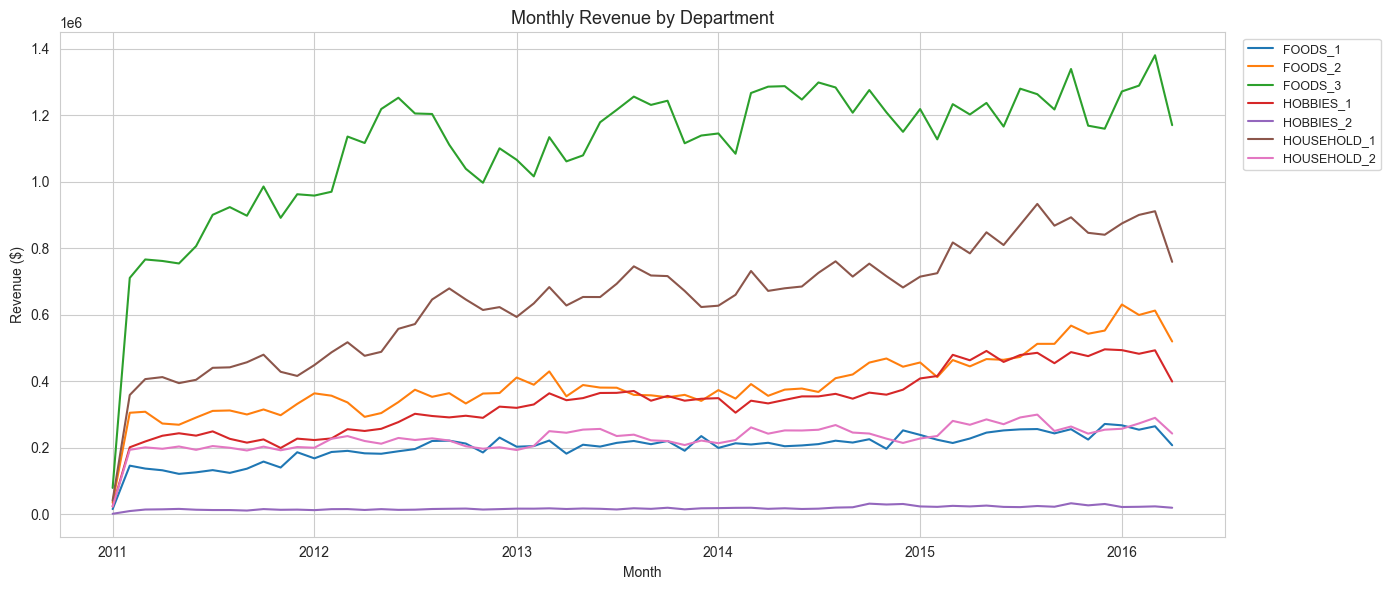

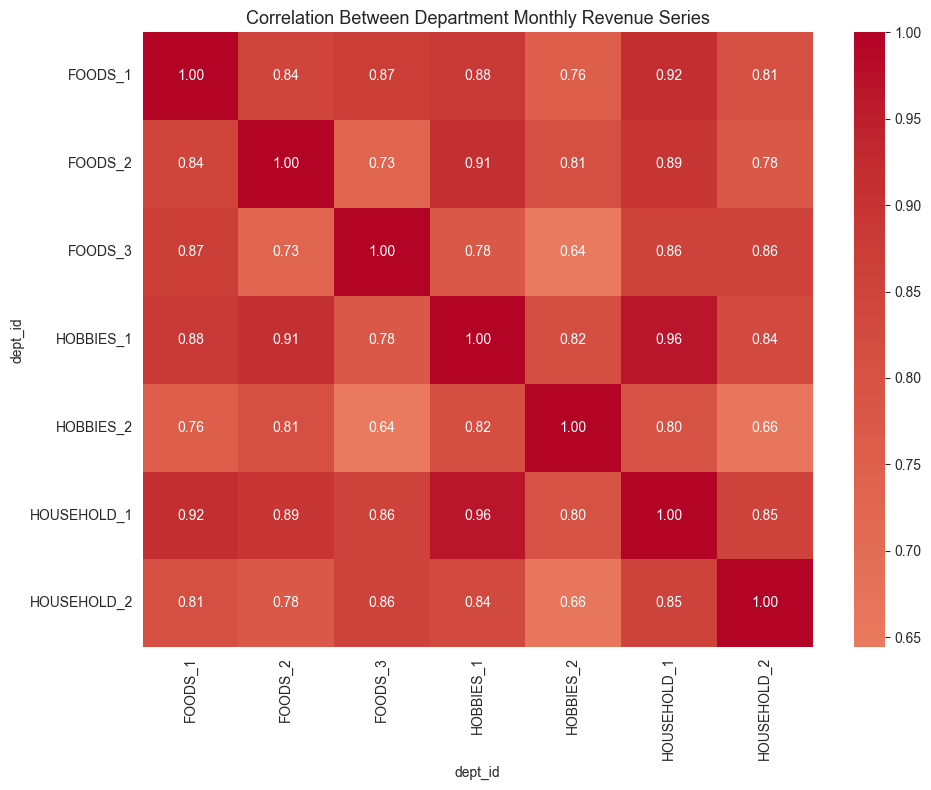

dept_id      FOODS_1  FOODS_2  FOODS_3  HOBBIES_1  HOBBIES_2  HOUSEHOLD_1  HOUSEHOLD_2
dept_id                                                                               
FOODS_1         1.00     0.84     0.87       0.88       0.76         0.92         0.81
FOODS_2         0.84     1.00     0.73       0.91       0.81         0.89         0.78
FOODS_3         0.87     0.73     1.00       0.78       0.64         0.86         0.86
HOBBIES_1       0.88     0.91     0.78       1.00       0.82         0.96         0.84
HOBBIES_2       0.76     0.81     0.64       0.82       1.00         0.80         0.66
HOUSEHOLD_1     0.92     0.89     0.86       0.96       0.80         1.00         0.85
HOUSEHOLD_2     0.81     0.78     0.86       0.84       0.66         0.85         1.00


In [13]:
dept_monthly = (
    df.groupby(['month_dt', 'dept_id'])['revenue']
    .sum()
    .reset_index()
)
dept_pivot = dept_monthly.pivot(index='month_dt', columns='dept_id', values='revenue')

# All departments on one chart
fig, ax = plt.subplots(figsize=(14, 6))
for col in dept_pivot.columns:
    ax.plot(dept_pivot.index, dept_pivot[col], linewidth=1.5, label=col)
ax.set_title('Monthly Revenue by Department', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = dept_pivot.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Between Department Monthly Revenue Series', fontsize=13)
plt.tight_layout()
plt.show()

print(corr.round(2).to_string())

## 14. Store-Level Analysis

We assess revenue distribution across the 10 stores and check whether stores 
have consistent histories. This determines whether store-level or aggregate 
modeling is more appropriate.

Revenue by Store:
store_id revenue_fmt   pct
    CA_3 $32,108,720 17.11
    CA_1 $22,520,252 12.00
    TX_2 $20,518,237 10.93
    TX_3 $17,796,728  9.48
    WI_2 $17,690,738  9.43
    CA_2 $17,409,445  9.28
    WI_3 $16,926,906  9.02
    TX_1 $15,729,162  8.38
    WI_1 $14,769,235  7.87
    CA_4 $12,207,147  6.50



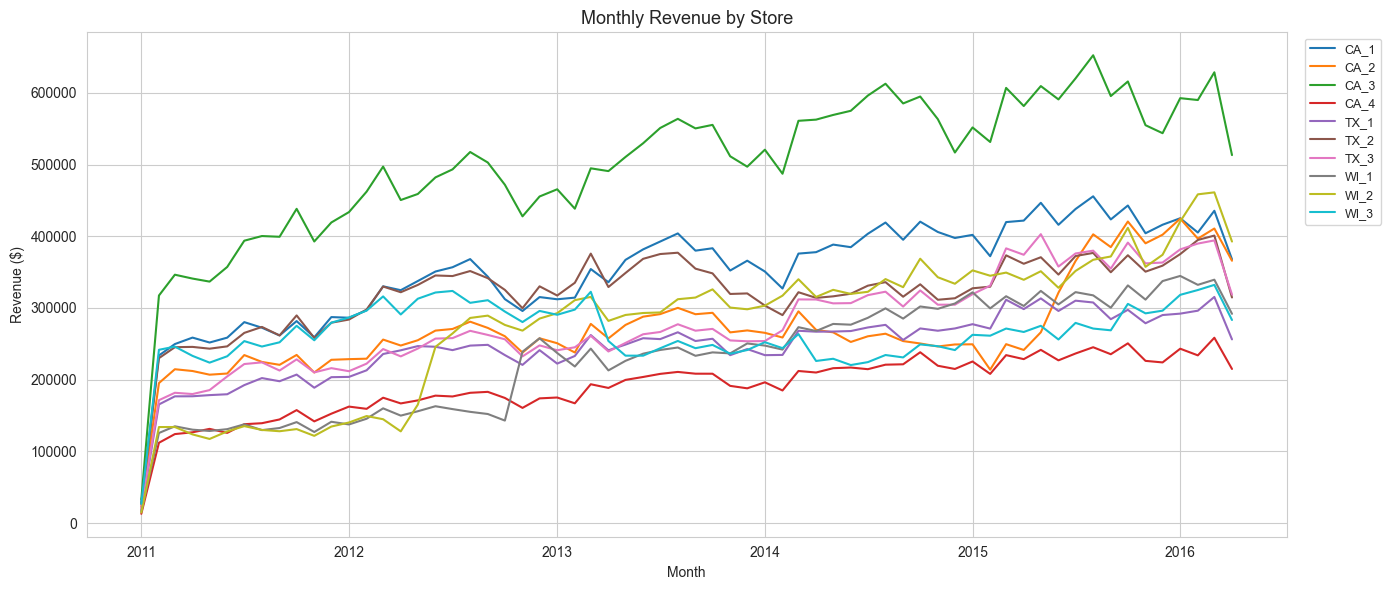

In [14]:
# Revenue by store
store_totals = (
    df.groupby('store_id')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
store_totals['pct'] = (store_totals['revenue'] / store_totals['revenue'].sum() * 100).round(2)
store_totals['revenue_fmt'] = store_totals['revenue'].apply(lambda x: f'${x:,.0f}')

print('Revenue by Store:')
print(store_totals[['store_id', 'revenue_fmt', 'pct']].to_string(index=False))
print()

# Monthly revenue per store
store_monthly = (
    df.groupby(['month_dt', 'store_id'])['revenue']
    .sum()
    .reset_index()
)
store_pivot = store_monthly.pivot(index='month_dt', columns='store_id', values='revenue')

fig, ax = plt.subplots(figsize=(14, 6))
for col in store_pivot.columns:
    ax.plot(store_pivot.index, store_pivot[col], linewidth=1.5, label=col)
ax.set_title('Monthly Revenue by Store', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 15. Product-Series Completeness

For individual-level SARIMA modeling we need product-store series with complete 
monthly histories. Products introduced mid-period will have gaps. We identify 
how many series are fully eligible for time series modeling.

Total months in dataset:              64
Total product-store series:           30,490
Series with all 64 months:            2,469
Series with < 64 months:              28,021

Active months distribution:
count    30490.0
mean        44.7
std         15.6
min          2.0
25%         33.0
50%         47.0
75%         59.0
max         64.0
Name: active_months, dtype: float64


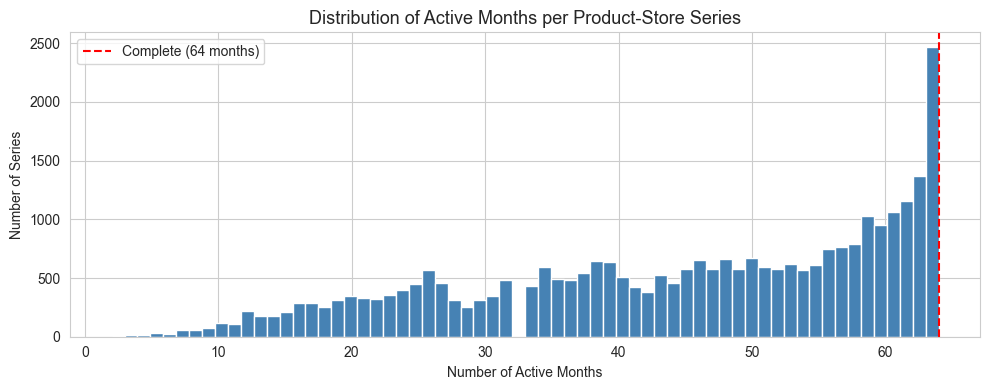

In [15]:
total_months = df['month_dt'].nunique()

# Count months with non-zero revenue per product-store series
series_months = (
    df[df['revenue'] > 0]
    .groupby('id')['month_dt']
    .nunique()
    .reset_index()
    .rename(columns={'month_dt': 'active_months'})
)

complete_series = series_months[series_months['active_months'] == total_months]

print(f'Total months in dataset:              {total_months}')
print(f'Total product-store series:           {series_months.shape[0]:,}')
print(f'Series with all {total_months} months:            {len(complete_series):,}')
print(f'Series with < {total_months} months:              {series_months.shape[0] - len(complete_series):,}')
print()
print('Active months distribution:')
print(series_months['active_months'].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(series_months['active_months'], bins=total_months, color='steelblue', edgecolor='white')
ax.axvline(total_months, color='red', linestyle='--', linewidth=1.5, label=f'Complete ({total_months} months)')
ax.set_title('Distribution of Active Months per Product-Store Series', fontsize=13)
ax.set_xlabel('Number of Active Months')
ax.set_ylabel('Number of Series')
ax.legend()
plt.tight_layout()
plt.show()

## 16. Representative Series Selection

We select one product-store series whose monthly revenue is closest to the median 
across all complete series. This series becomes our individual-level SARIMA proof 
of concept carried through all modeling notebooks.

Median total revenue across complete series: $7,703.60
Representative series ID:                    FOODS_3_163_CA_3_validation
Their total revenue:                         $7,703.60


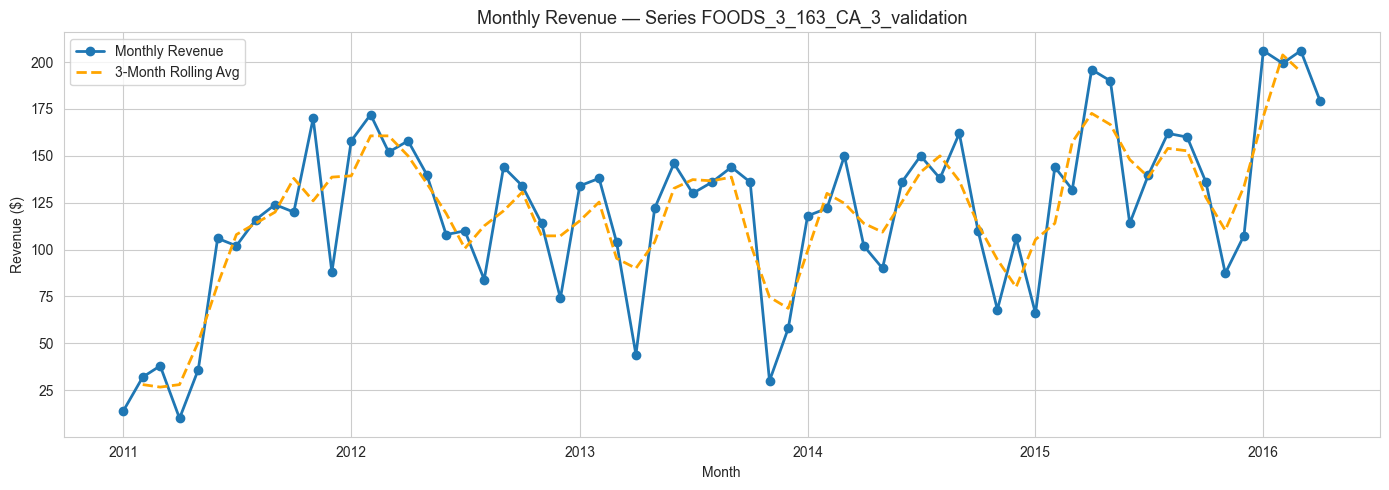

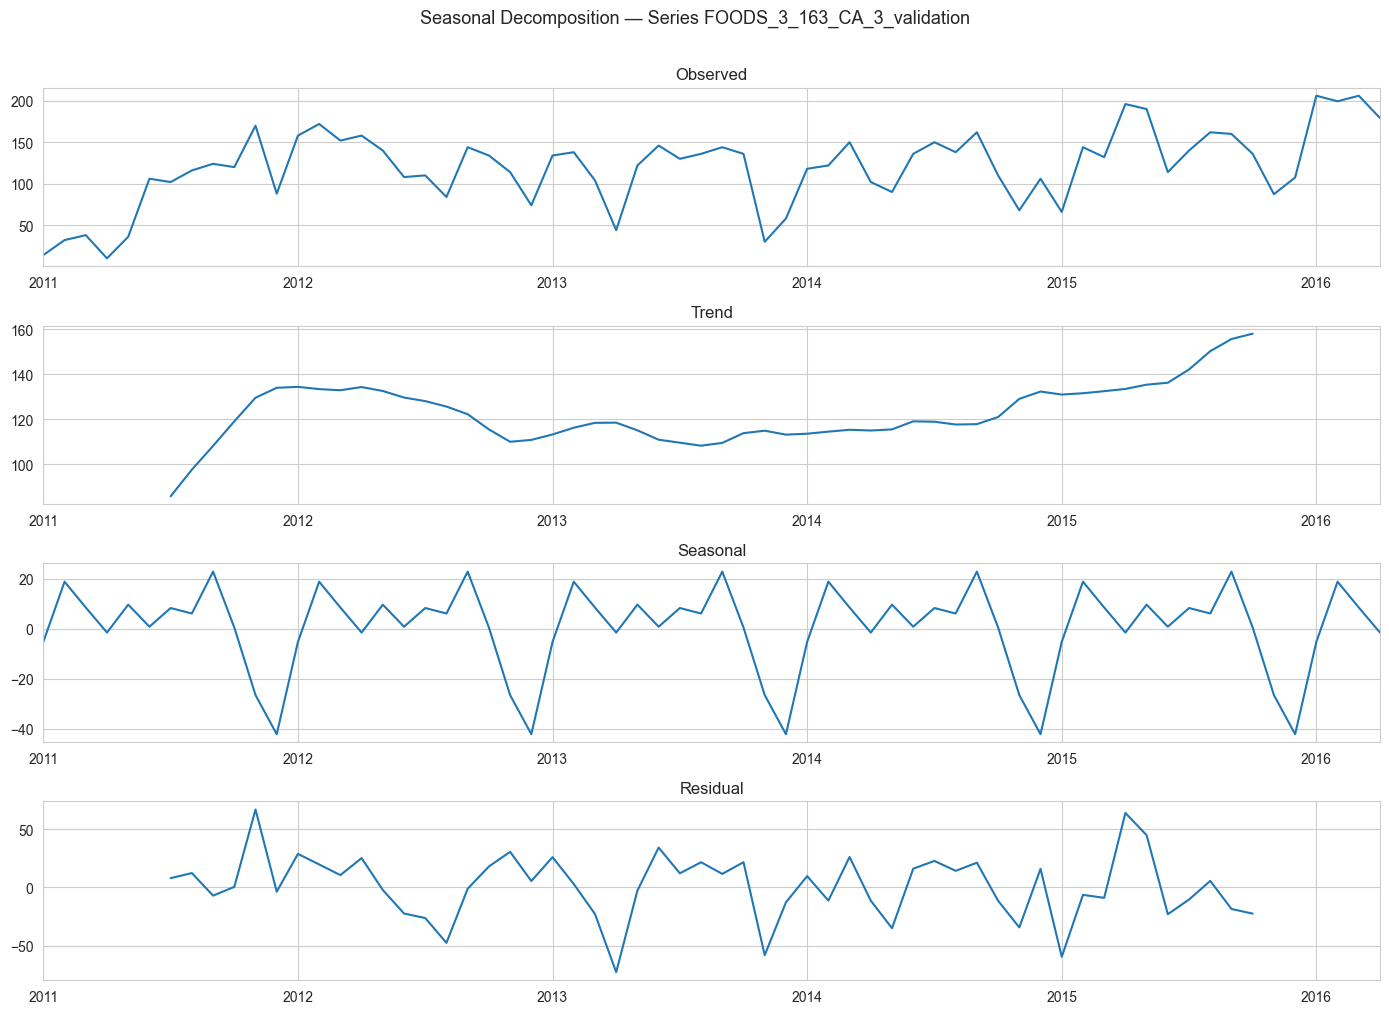

In [16]:
# Build monthly revenue table for all complete series
monthly_all_series = (
    df.groupby(['id', 'month_dt'])['revenue']
    .sum()
    .reset_index()
    .rename(columns={'revenue': 'total_revenue'})
)

# Filter to complete series only
complete_ids = complete_series['id'].tolist()
monthly_complete = monthly_all_series[monthly_all_series['id'].isin(complete_ids)]

# Find series closest to median total revenue
series_totals = (
    monthly_complete.groupby('id')['total_revenue']
    .sum()
    .reset_index()
    .rename(columns={'total_revenue': 'total'})
)
median_total = series_totals['total'].median()
series_totals['dist'] = (series_totals['total'] - median_total).abs()
rep_series = series_totals.loc[series_totals['dist'].idxmin(), 'id']

print(f'Median total revenue across complete series: ${median_total:,.2f}')
print(f'Representative series ID:                    {rep_series}')
print(f'Their total revenue:                         ${series_totals.loc[series_totals["id"] == rep_series, "total"].values[0]:,.2f}')

# Plot representative series
rep_monthly = monthly_complete[monthly_complete['id'] == rep_series].copy()
rep_monthly['rolling_3'] = rep_monthly['total_revenue'].rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rep_monthly['month_dt'], rep_monthly['total_revenue'], marker='o', linewidth=2, label='Monthly Revenue')
ax.plot(rep_monthly['month_dt'], rep_monthly['rolling_3'], linewidth=2, linestyle='--', color='orange', label='3-Month Rolling Avg')
ax.set_title(f'Monthly Revenue — Series {rep_series}', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.show()

# Seasonal decomposition for representative series
rep_indexed = rep_monthly.set_index('month_dt')['total_revenue']
rep_decomp = seasonal_decompose(rep_indexed, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
rep_decomp.observed.plot(ax=axes[0], title='Observed')
rep_decomp.trend.plot(ax=axes[1],    title='Trend')
rep_decomp.seasonal.plot(ax=axes[2], title='Seasonal')
rep_decomp.resid.plot(ax=axes[3],    title='Residual')
for ax in axes:
    ax.set_xlabel('')
plt.suptitle(f'Seasonal Decomposition — Series {rep_series}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 17. Price Volatility Analysis

Unlike synthetic data, M5 products have prices that change over time. Price 
volatility is a real feature that affects demand and will be an important 
predictor in our XGBoost model. We quantify how much prices change across 
departments.

Price statistics by department (cv% = coefficient of variation):
    dept_id  mean_price  std_price  min_price  max_price  cv_%
    FOODS_1        3.37       2.10       0.07      12.98  62.3
    FOODS_2        4.08       2.60       0.20      13.98  63.7
    FOODS_3        2.84       1.76       0.01      19.48  62.0
  HOBBIES_1        6.21       5.16       0.01      30.98  83.1
  HOBBIES_2        2.69       1.89       0.05       9.97  70.3
HOUSEHOLD_1        5.05       3.61       0.01      29.97  71.5
HOUSEHOLD_2        5.86       3.07       0.05     107.32  52.4


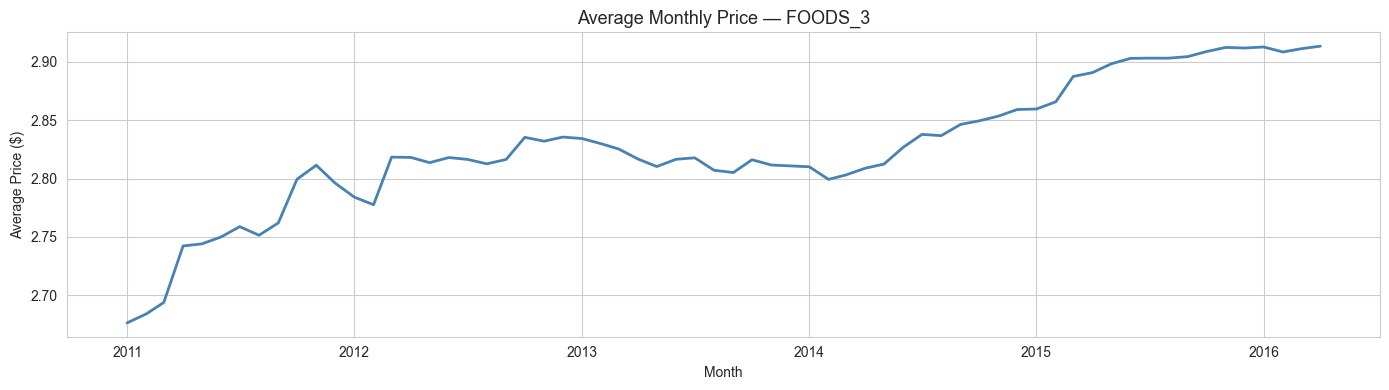

In [17]:
# Price volatility per department
price_stats = (
    df[df['sell_price'] > 0]
    .groupby('dept_id')['sell_price']
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
    .reset_index()
)
price_stats['cv'] = (price_stats['std'] / price_stats['mean'] * 100).round(1)  # coefficient of variation
price_stats.columns = ['dept_id', 'mean_price', 'std_price', 'min_price', 'max_price', 'cv_%']

print('Price statistics by department (cv% = coefficient of variation):')
print(price_stats.to_string(index=False))

# Price trend over time for top department
top_dept = dept_totals.iloc[0]['dept_id']
price_trend = (
    df[(df['dept_id'] == top_dept) & (df['sell_price'] > 0)]
    .groupby('month_dt')['sell_price']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(price_trend['month_dt'], price_trend['sell_price'], linewidth=2, color='steelblue')
ax.set_title(f'Average Monthly Price — {top_dept}', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

## 18. Save Processed Files

We save four files that feed directly into the modeling notebooks. The long-format 
transaction table is the foundation for XGBoost feature engineering. The monthly 
series files are inputs for SARIMA and Prophet.

In [18]:
os.makedirs('../data/processed', exist_ok=True)

# 1. Full cleaned long-format dataframe
df.to_csv('../data/processed/sales_clean.csv', index=False)
print(f'sales_clean.csv saved:              {df.shape[0]:,} rows × {df.shape[1]} cols')

# 2. Aggregate monthly revenue series
monthly[['month_dt', 'total_revenue']].to_csv('../data/processed/monthly_aggregate.csv', index=False)
print(f'monthly_aggregate.csv saved:        {monthly.shape[0]} rows × 2 cols')

# 3. Representative series monthly revenue
rep_monthly[['month_dt', 'total_revenue']].to_csv(
    f'../data/processed/monthly_series_{rep_series}.csv', index=False
)
print(f'monthly_series_{rep_series}.csv saved: {rep_monthly.shape[0]} rows × 2 cols')

# 4. All complete series monthly revenue — XGBoost input
monthly_complete.to_csv('../data/processed/monthly_all_series.csv', index=False)
print(f'monthly_all_series.csv saved:       {monthly_complete.shape[0]:,} rows × 3 cols')

print()
print('All files saved to ../data/processed/')
print(f'Representative series ID: {rep_series}')
print('Hardcode this value in all modeling notebooks.')

KeyboardInterrupt: 

## 19. Key Findings & EDA Summary

A complete summary of what the data revealed and how each finding drives 
modeling decisions in subsequent notebooks.

### Dataset & Quality
- **30,490 product-store time series** across 3,049 products, 10 stores, 
  3 states (CA, TX, WI) from Jan 2011 – May 2016
- Data comes in wide format (1,913 day columns) — reshaped to long format 
  before any analysis
- Revenue computed as `units_sold × sell_price` after joining 3 source files
- Missing prices filled with 0 (products not yet stocked = no revenue)

### What Makes This Data Real
- **Non-flat residuals** — genuine noise from promotions, weather, local events 
  that no seasonal model fully captures
- **Price volatility** — prices change over time, especially in FOODS department
- **Holiday effects** — Thanksgiving, Christmas, Super Bowl create measurable 
  demand spikes
- **SNAP effects** — government benefit days create state-specific spending 
  patterns, especially in FOODS
- **Product introductions** — not all series are complete, reflecting real 
  retail shelf dynamics

### Modeling Decisions Locked In
| Decision | Justification |
|---|---|
| SARIMA with period=12 | Seasonal decomposition confirms annual cycle |
| Additive vs multiplicative | Assess after viewing trend — decide in SARIMA notebook |
| Aggregate + representative series | Both modeled separately, different variance profiles |
| XGBoost features: holidays, SNAP, price | Quantified impact confirmed in EDA |
| Walk-forward CV with 5 years of data | Enough history for multiple folds unlike synthetic data |
| Log transform — defer decision | Assess monthly aggregate variance in SARIMA notebook |

### Limitations
- Revenue is derived (`units × price`), not directly observed — price join 
  introduces minor gaps for new products
- 5 years of monthly data = ~60 points for aggregate SARIMA — sufficient 
  but not abundant
- Product-level series are sparse and noisy — individual series forecasting 
  is less reliable than aggregate

---

### Files Saved to `data/processed/`

| File | Rows | Used In |
|---|---|---|
| `sales_clean.csv` | ~58M | XGBoost feature engineering |
| `monthly_aggregate.csv` | ~60 | SARIMA, Prophet — aggregate series |
| `monthly_series_[id].csv` | ~60 | SARIMA, Prophet — individual series |
| `monthly_all_series.csv` | varies | XGBoost — all series monthly totals |

**Hardcoded values for all modeling notebooks:**
- Representative series: see output of Section 16
- Seasonal period: `12`
- Train/test split: first 48 months train, last 12 months test